# PCA vs scGPT on the learnable-drug subset (`auc_z`)

The **best-case diagnostic** the TODO asks for. `2_training` showed that on all 545 drugs the model does not
rank cell lines at all (mean per-drug Spearman ≈ 0 for both representations), but that experiment
could not separate two very different explanations:

1. the **representation** is inadequate, or
2. **most drugs have no cross-line signal to find** — they are flat, inert, or barely screened, so
   even a perfect model would score ≈ 0 on them and drown the few real ones in the average.

So here the drug axis is collapsed to the **5 drugs that survive the harsh learnability filter** of
[`08_learnability_filter.ipynb`](08_learnability_filter.ipynb) — high coverage, wide AUC spread, and a
real population of both killed *and* surviving cell lines. If a transcriptomic signal exists anywhere
in this dataset, it exists here. **If PCA and scGPT both fail on these 5, explanation (2) is settled
and the ceiling is the label, not the gene representation.**

Everything trains through `train_multitask.train_rep` / the same `MultiDrugDataset` + `OncoMLP` +
`train_model` the CLI uses, on the matched `(128,64)` trunk and 512-d input — so only the
representation differs, and the notebook cannot drift from the command line.

**Two evaluations, because the fixed split is small.** With K=5 the fixed `split_ctrp` val fold holds
only **27 cell lines**, and a Spearman over 27 points is barely more than noise. So the headline
metric is computed on **cross-validated out-of-fold predictions**: 5-fold GroupKFold over the 153
train+val lines (test held out entirely, exactly as `2_training` §2 does), giving every line a prediction from
a model that never saw it → a per-drug correlation over **~150 lines** instead of 27.

In [1]:
import json
import os
import sys
from pathlib import Path

NB_DIR = Path.cwd()
ROOT = NB_DIR.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)                      # runs/ lives at the project root

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import GroupKFold
from torch.utils.data import DataLoader

from scripts.model.OncoMLP import OncoMLP
from scripts.model.dataset import MultiDrugDataset
from scripts.preprocessing.layout import PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS, train_rep
from scripts.training.training_utils import TrainConfig, train_model

OUT = NB_DIR / 'outputs'; OUT.mkdir(exist_ok=True)

SCORE, VARIANT = 'auc_z', 'hvg5000'
REPS = ['X_pca', 'X_scGPT']
SEED = 42

paths = PipelinePaths.build(None, VARIANT, SCORE)
config = TrainConfig(epochs=50, seed=SEED)          # same defaults as the CLI
print('matched trunk :', DEFAULT_HIDDEN_DIMS)
print('targets file  :', paths.targets_h5ad.name)

matched trunk : {'X_pca': (128, 64), 'X_scGPT': (128, 64)}
targets file  : SCP542_CCLE_scGPT_human_embeddings_with_targets_auc_z.h5ad


## 1. The 5 drugs — read from `learnability_filter`, not hard-coded

Taken straight from `outputs/learnability/ctrp_drug_learnability_auc.csv`, so re-running `learnability_filter` with different gates
automatically changes what gets trained here.

In [2]:
lrn = pd.read_csv(OUT / 'learnability' / 'ctrp_drug_learnability_auc.csv')
DRUGS = (lrn[lrn['selected']]
         .sort_values('learnability', ascending=False)
         ['drug'].tolist())

print(f'{int(lrn["selected"].sum())} / {len(lrn)} drugs selected by the learnability filter:')
print(lrn[lrn['drug'].isin(DRUGS)][
    ['rank', 'drug', 'n_lines', 'auc_std', 'dyn_range', 'n_sens', 'n_res', 'learnability']
].to_string(index=False))

adata = sc.read_h5ad(paths.targets_h5ad)
print(f'\n{adata.n_obs} cells | split_ctrp:',
      adata.obs['split_ctrp'].value_counts().to_dict())

10 / 545 drugs selected by the learnability filter:
 rank         drug  n_lines  auc_std  dyn_range  n_sens  n_res  learnability
    1    daporinad      163  0.25318    0.80344      40     43            40
    2        ml210      170  0.19277    0.57519      39     56            39
    3    gsk461364      165  0.24443    0.79848      61     35            35
    4 oligomycin a      165  0.22740    0.78903      35     36            35
    5      kx2-391      175  0.17853    0.58914      34     33            33
    6 methotrexate      170  0.20504    0.61891      52     31            31
    7   rigosertib      172  0.15673    0.48713      29     33            29
    8     snx-2112      179  0.14761    0.47322      28     29            28
    9    dasatinib      177  0.15527    0.46846      35     27            27
   10        ml162      176  0.15625    0.49567      48     27            27



53513 cells | split_ctrp: {'train': 34126, 'val': 7121, 'unassigned': 6286, 'test': 5980}


## 2. Train both representations on the fixed split

`train_rep` = the exact call the CLI makes:

```bash
uv run scripts/training/train_multitask.py --variant hvg5000 --score auc_z \
    --use-rep X_scGPT --drugs 1s,3r-rsl-3 kx2-391 cay10618 ml162 dasatinib
```

Each run writes `runs/<timestamp>_<tag>/` (`best_model.pt`, `summary.json`, `per_drug_results.csv`)
and is registered in `runs/runs_index.csv`, so these are versioned like every other run.

Remember the scale: the target is z-scored per drug, so **MSE = 1.0 is exactly the per-drug-mean null
model**. Anything below 1.0 is real signal; anything above means the head is worse than predicting the
drug's average.

In [3]:
results = {}
for rep in REPS:
    print(f'\n=== {rep} ===')
    results[rep] = train_rep(
        use_rep=rep,
        h5ad_path=str(paths.targets_h5ad),
        config=config,
        drugs=DRUGS,
        data_root=str(paths.data_root),
        variant=VARIANT,
        tag=f'learnable_{rep}',
        print_comparison=False,
    )

fixed = []
for rep in REPS:
    r = results[rep]
    for k, d in enumerate(r['drug_names']):
        fixed.append({
            'rep': rep, 'drug': d,
            'model_mse': r['model_per_drug_val_mse'][k],
            'baseline_mse': r['baseline_per_drug_val_mse'][k],
            'delta': r['model_per_drug_val_mse'][k] - r['baseline_per_drug_val_mse'][k],
            'n_val_cells': r['n_val_per_drug'][k],
        })
fixed = pd.DataFrame(fixed)
fixed['beats_baseline'] = fixed['delta'] < 0

print('\nFixed split — per-drug val MSE (1.0 = per-drug-mean null model):')
print(fixed.round(3).to_string(index=False))
print('\nheads beating baseline:',
      fixed.groupby('rep')['beats_baseline'].sum().to_dict(), f'out of {len(DRUGS)}')


=== X_pca ===
Loading multi-drug data from /Users/selin/Desktop/OncoTox/data/processed/scRNAseq_SCP542/hvg5000/SCP542_CCLE_scGPT_human_embeddings_with_targets_auc_z.h5ad...


Loaded 34126 cells for the 'train' set. K=10 drugs | mean drugs/cell=9.6 | min drug coverage=30200 cells | max drug coverage=34126 cells.
Loading multi-drug data from /Users/selin/Desktop/OncoTox/data/processed/scRNAseq_SCP542/hvg5000/SCP542_CCLE_scGPT_human_embeddings_with_targets_auc_z.h5ad...


Loaded 7121 cells for the 'val' set. K=10 drugs | mean drugs/cell=9.7 | min drug coverage=6144 cells | max drug coverage=7121 cells.
[learnable5_X_pca] Per-drug-mean sanity baseline ready: mean baseline val MSE = 1.0570 over 10 / 10 heads.
Starting multi-task training: rep=X_pca, K=10 drugs, input_dim=512, hidden_dims=(128, 64).
[learnable5_X_pca] Training on device: mps
[learnable5_X_pca] Multi-task mode detected (masked MSE).


[learnable5_X_pca] Epoch [01/50] | Train MSE: 0.5312 | Val MSE: 0.9926 | LR: 1.0e-03  <- best
  best : ml210:0.573(n=7015), ml162:0.681(n=7121), dasatinib:0.771(n=7121), gsk461364:0.867(n=6522), snx-2112:1.005(n=7121)
  worst: oligomycin a:1.513(n=6144), kx2-391:1.248(n=7121), rigosertib:1.186(n=7121), methotrexate:1.073(n=6710), daporinad:1.071(n=7006)


[learnable5_X_pca] Epoch [05/50] | Train MSE: 0.2540 | Val MSE: 1.0275 | LR: 1.0e-03
  best : ml210:0.576(n=7015), ml162:0.706(n=7121), gsk461364:0.853(n=6522), dasatinib:0.883(n=7121), snx-2112:0.982(n=7121)
  worst: oligomycin a:1.555(n=6144), kx2-391:1.390(n=7121), rigosertib:1.264(n=7121), methotrexate:1.089(n=6710), daporinad:1.031(n=7006)


...

Loaded 7121 cells for the 'val' set. K=10 drugs | mean drugs/cell=9.7 | min drug coverage=6144 cells | max drug coverage=7121 cells.
[learnable5_X_scGPT] Per-drug-mean sanity baseline ready: mean baseline val MSE = 1.0570 over 10 / 10 heads.
Starting multi-task training: rep=X_scGPT, K=10 drugs, input_dim=512, hidden_dims=(128, 64).
[learnable5_X_scGPT] Training on device: mps
[learnable5_X_scGPT] Multi-task mode detected (masked MSE).


[learnable5_X_scGPT] Epoch [01/50] | Train MSE: 0.7919 | Val MSE: 0.8982 | LR: 1.0e-03  <- best
  best : ml210:0.534(n=7015), ml162:0.665(n=7121), gsk461364:0.668(n=6522), dasatinib:0.689(n=7121), snx-2112:0.898(n=7121)
  worst: oligomycin a:1.496(n=6144), rigosertib:1.094(n=7121), kx2-391:1.054(n=7121), methotrexate:0.987(n=6710), daporinad:0.962(n=7006)


[learnable5_X_scGPT] Epoch [05/50] | Train MSE: 0.5884 | Val MSE: 0.9441 | LR: 1.0e-03
  best : ml210:0.598(n=7015), dasatinib:0.687(n=7121), gsk461364:0.701(n=6522), ml162:0.713(n=7121), daporinad:0.948(n=7006)
  worst: oligomycin a:1.558(n=6144), kx2-391:1.140(n=7121), rigosertib:1.121(n=7121), methotrexate:1.079(n=6710), snx-2112:0.961(n=7121)


[learnable5_X_scGPT] Epoch [10/50] | Train MSE: 0.5305 | Val MSE: 0.9241 | LR: 2.5e-04
  best : ml210:0.553(n=7015), dasatinib:0.642(n=7121), ml162:0.669(n=7121), gsk461364:0.691(n=6522), daporinad:0.948(n=7006)
  worst: oligomycin a:1.527(n=6144), rigosertib:1.153(n=7121), methotrexate:1.114(n=6710), kx2-391:1.060(n=7121), snx-2112:0.953(n=7121)


[learnable5_X_scGPT] Early stopping at epoch 11 (no val improvement for 10 epochs).
[learnable5_X_scGPT] Training complete. Best Val MSE: 0.8982 at epoch 1.

[multitask_X_scGPT_subset_K10] Saved run artifacts to: runs/20260714_185704_multitask_X_scGPT_subset_K10

Fixed split — per-drug val MSE (1.0 = per-drug-mean null model):
    rep         drug  model_mse  baseline_mse  delta  n_val_cells  beats_baseline
  X_pca    daporinad      1.071         1.042  0.029       7006.0           False
  X_pca        ml210      0.573         1.013 -0.440       7015.0            True
  X_pca    gsk461364      0.867         0.743  0.123       6522.0           False
  X_pca oligomycin a      1.513         1.515 -0.003       6144.0            True
  X_pca      kx2-391      1.248         0.996  0.252       7121.0           False
  X_pca methotrexate      1.073         0.882  0.191       6710.0           False
  X_pca   rigosertib      1.186         1.186  0.000       7121.0           False
  X_pca     snx

## 3. The honest metric — cross-validated per-drug correlation

MSE says *how close* the prediction is; it does not say whether the model **ranks cell lines**
correctly, which is the whole clinical point ("is this line sensitive or resistant?"). `2_training` §3
established per-drug Spearman across held-out lines as the metric that matters.

5-fold GroupKFold over the 153 `train`+`val` lines (test untouched). Every fold trains a fresh model
and predicts its held-out lines, so pooling the folds gives an **out-of-fold prediction for every
line** — a Spearman over ~150 lines rather than the 27 the fixed split would allow. Per-cell
predictions are averaged back to one value per cell line first (the label is per-line, so this is the
resolution the question actually lives at).

In [4]:
eligible = adata.obs['split_ctrp'].isin(['train', 'val']).to_numpy()
groups = adata.obs['Cell_line'].astype(str).to_numpy()
idx = np.flatnonzero(eligible)

oof = {}          # rep -> (n_cells_eligible, K) out-of-fold predictions, NaN where not predicted
for rep in REPS:
    pred = np.full((adata.n_obs, len(DRUGS)), np.nan, dtype=float)
    gkf = GroupKFold(n_splits=5)
    for fold, (tr, va) in enumerate(gkf.split(idx, groups=groups[idx]), start=1):
        tr_cells = np.zeros(adata.n_obs, dtype=bool); tr_cells[idx[tr]] = True
        va_cells = np.zeros(adata.n_obs, dtype=bool); va_cells[idx[va]] = True

        tr_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=tr_cells, drugs=DRUGS)
        va_ds = MultiDrugDataset(adata=adata, use_rep=rep, cell_mask=va_cells, drugs=DRUGS)
        model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                        dropout_rate=0.5, input_dropout=0.1, norm='layer',
                        output_dim=len(tr_ds.drug_names))
        best, _ = train_model(
            model,
            DataLoader(tr_ds, batch_size=128, shuffle=True),
            DataLoader(va_ds, batch_size=128, shuffle=False),
            config=config, tag=f'oof{fold}_{rep}', drug_names=tr_ds.drug_names,
        )
        best = best.to('cpu').eval()          # train_model leaves it on mps/cuda
        with torch.no_grad():
            X = torch.tensor(np.asarray(adata.obsm[rep], dtype=np.float32)[va_cells])
            pred[va_cells] = best(X).numpy()
    oof[rep] = pred
    print(f'{rep}: out-of-fold predictions for {int(np.isfinite(pred[:, 0]).sum())} cells')

Loaded 33000 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.6 | min drug coverage=29231 cells | max drug coverage=33000 cells.
Loaded 8247 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.6 | min drug coverage=7566 cells | max drug coverage=8247 cells.
[oof1_X_pca] Training on device: mps
[oof1_X_pca] Multi-task mode detected (masked MSE).


[oof1_X_pca] Epoch [01/50] | Train MSE: 0.5666 | Val MSE: 0.9042 | LR: 1.0e-03  <- best
  best : ml210:0.604(n=7566), dasatinib:0.620(n=7918), ml162:0.656(n=8247), snx-2112:0.762(n=8247), oligomycin a:0.804(n=7650)
  worst: kx2-391:1.755(n=8183), gsk461364:1.103(n=7671), rigosertib:0.952(n=8039), daporinad:0.898(n=7975), methotrexate:0.863(n=7768)


[oof1_X_pca] Epoch [04/50] | Train MSE: 0.2795 | Val MSE: 0.8795 | LR: 1.0e-03  <- best
  best : ml210:0.580(n=7566), dasatinib:0.646(n=7918), ml162:0.680(n=8247), snx-2112:0.692(n=8247), oligomycin a:0.841(n=7650)
  worst: kx2-391:1.454(n=8183), gsk461364:1.053(n=7671), daporinad:1.020(n=7975), methotrexate:0.958(n=7768), rigosertib:0.859(n=8039)


[oof1_X_pca] Epoch [05/50] | Train MSE: 0.2685 | Val MSE: 0.8867 | LR: 1.0e-03
  best : ml210:0.567(n=7566), dasatinib:0.619(n=7918), ml162:0.655(n=8247), snx-2112:0.686(n=8247), oligomycin a:0.828(n=7650)
  worst: kx2-391:1.546(n=8183), gsk461364:1.171(n=7671), daporinad:0.983(n=7975), methotrexate:0.941(n=7768), rigosertib:0.860(n=8039)


[oof1_X_pca] Epoch [07/50] | Train MSE: 0.2578 | Val MSE: 0.8742 | LR: 1.0e-03  <- best
  best : dasatinib:0.586(n=7918), ml210:0.600(n=7566), ml162:0.651(n=8247), snx-2112:0.676(n=8247), oligomycin a:0.782(n=7650)
  worst: kx2-391:1.677(n=8183), gsk461364:1.067(n=7671), daporinad:0.923(n=7975), rigosertib:0.882(n=8039), methotrexate:0.879(n=7768)


...

[oof4_X_scGPT] Epoch [15/50] | Train MSE: 0.5300 | Val MSE: 0.8635 | LR: 2.5e-04
  best : gsk461364:0.609(n=8123), ml162:0.626(n=8239), methotrexate:0.654(n=7927), dasatinib:0.657(n=8239), ml210:0.688(n=7713)
  worst: daporinad:1.832(n=7043), snx-2112:0.986(n=8239), kx2-391:0.953(n=8051), oligomycin a:0.933(n=7497), rigosertib:0.822(n=7968)
[oof4_X_scGPT] Early stopping at epoch 15 (no val improvement for 10 epochs).
[oof4_X_scGPT] Training complete. Best Val MSE: 0.8201 at epoch 5.
Loaded 32995 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.7 | min drug coverage=29150 cells | max drug coverage=32995 cells.
Loaded 8252 cells for the 'custom-mask' set. K=10 drugs | mean drugs/cell=9.5 | min drug coverage=6984 cells | max drug coverage=8252 cells.
[oof5_X_scGPT] Training on device: mps
[oof5_X_scGPT] Multi-task mode detected (masked MSE).


[oof5_X_scGPT] Epoch [01/50] | Train MSE: 0.7930 | Val MSE: 0.8593 | LR: 1.0e-03  <- best
  best : ml162:0.584(n=8252), dasatinib:0.605(n=7976), methotrexate:0.606(n=7734), snx-2112:0.782(n=8252), ml210:0.810(n=8252)
  worst: kx2-391:1.197(n=7854), oligomycin a:1.155(n=6984), gsk461364:1.057(n=7372), daporinad:0.952(n=8056), rigosertib:0.910(n=7652)


[oof5_X_scGPT] Epoch [05/50] | Train MSE: 0.5914 | Val MSE: 0.9258 | LR: 1.0e-03
  best : dasatinib:0.545(n=7976), ml162:0.687(n=8252), methotrexate:0.703(n=7734), ml210:0.825(n=8252), daporinad:0.995(n=8056)
  worst: kx2-391:1.382(n=7854), gsk461364:1.090(n=7372), snx-2112:1.029(n=8252), rigosertib:1.027(n=7652), oligomycin a:1.008(n=6984)


[oof5_X_scGPT] Epoch [10/50] | Train MSE: 0.5360 | Val MSE: 0.8970 | LR: 2.5e-04
  best : dasatinib:0.530(n=7976), methotrexate:0.641(n=7734), ml162:0.645(n=8252), ml210:0.802(n=8252), daporinad:0.948(n=8056)
  worst: kx2-391:1.402(n=7854), gsk461364:1.038(n=7372), rigosertib:1.032(n=7652), snx-2112:0.987(n=8252), oligomycin a:0.981(n=6984)


[oof5_X_scGPT] Early stopping at epoch 11 (no val improvement for 10 epochs).
[oof5_X_scGPT] Training complete. Best Val MSE: 0.8593 at epoch 1.
X_scGPT: out-of-fold predictions for 41247 cells


In [5]:
Y = np.asarray(adata.obsm['Y_ctrp'], dtype=float)
M = np.asarray(adata.obsm['M_ctrp'], dtype=bool)
all_drugs = list(adata.uns['ctrp_drugs'])
kcol = [all_drugs.index(d) for d in DRUGS]          # column of each kept drug in the full matrix

lines_elig = np.unique(groups[eligible])
recs, per_line = [], {}
for rep in REPS:
    for j, (d, k) in enumerate(zip(DRUGS, kcol)):
        t, p, ln = [], [], []
        for line in lines_elig:
            ci = np.flatnonzero((groups == line) & eligible)
            obs = ci[M[ci, k] & np.isfinite(oof[rep][ci, j])]
            if obs.size == 0:
                continue
            t.append(Y[obs, k].mean())             # true auc_z for this line (constant within line)
            p.append(oof[rep][obs, j].mean())      # mean out-of-fold prediction over the line's cells
            ln.append(line)
        t, p = np.asarray(t), np.asarray(p)
        per_line[(rep, d)] = (t, p)
        recs.append({'rep': rep, 'drug': d, 'n_lines': t.size,
                     'spearman': spearmanr(p, t).statistic,
                     'pearson': pearsonr(p, t)[0],
                     'pred_std': p.std()})

corr = pd.DataFrame(recs)
print('Cross-validated per-drug correlation (pred vs true auc_z, across held-out cell lines):')
print(corr.round(3).to_string(index=False))
print()
print(corr.groupby('rep')[['spearman', 'pearson', 'pred_std']].mean().round(3).to_string())
corr.to_csv(OUT / 'learnability' / 'learnable_per_drug_correlation.csv', index=False)
fixed.to_csv(OUT / 'learnability' / 'learnable_fixed_split_mse.csv', index=False)

Cross-validated per-drug correlation (pred vs true auc_z, across held-out cell lines):
    rep         drug  n_lines  spearman  pearson  pred_std
  X_pca    daporinad      141     0.158    0.181     0.423
  X_pca        ml210      146     0.614    0.594     0.613
  X_pca    gsk461364      144     0.358    0.342     0.463
  X_pca oligomycin a      141     0.296    0.304     0.422
  X_pca      kx2-391      149     0.116    0.105     0.425
  X_pca methotrexate      147     0.286    0.281     0.423
  X_pca   rigosertib      146     0.259    0.237     0.434
  X_pca     snx-2112      153     0.382    0.377     0.507
  X_pca    dasatinib      151     0.541    0.548     0.640
  X_pca        ml162      152     0.608    0.606     0.609
X_scGPT    daporinad      141     0.142    0.128     0.237
X_scGPT        ml210      146     0.627    0.613     0.559
X_scGPT    gsk461364      144     0.499    0.519     0.394
X_scGPT oligomycin a      141     0.226    0.231     0.366
X_scGPT      kx2-391      14

## 4. Predicted vs true, per drug

The diagnostic plot. Each point is a **held-out cell line** (out-of-fold). A model that has learned
sensitivity produces a positive diagonal trend. A model that has only learned the drug's mean produces
a **horizontal cloud** — predictions collapsed into a narrow band regardless of the true response
(`pred_std` in the table above quantifies exactly that collapse).

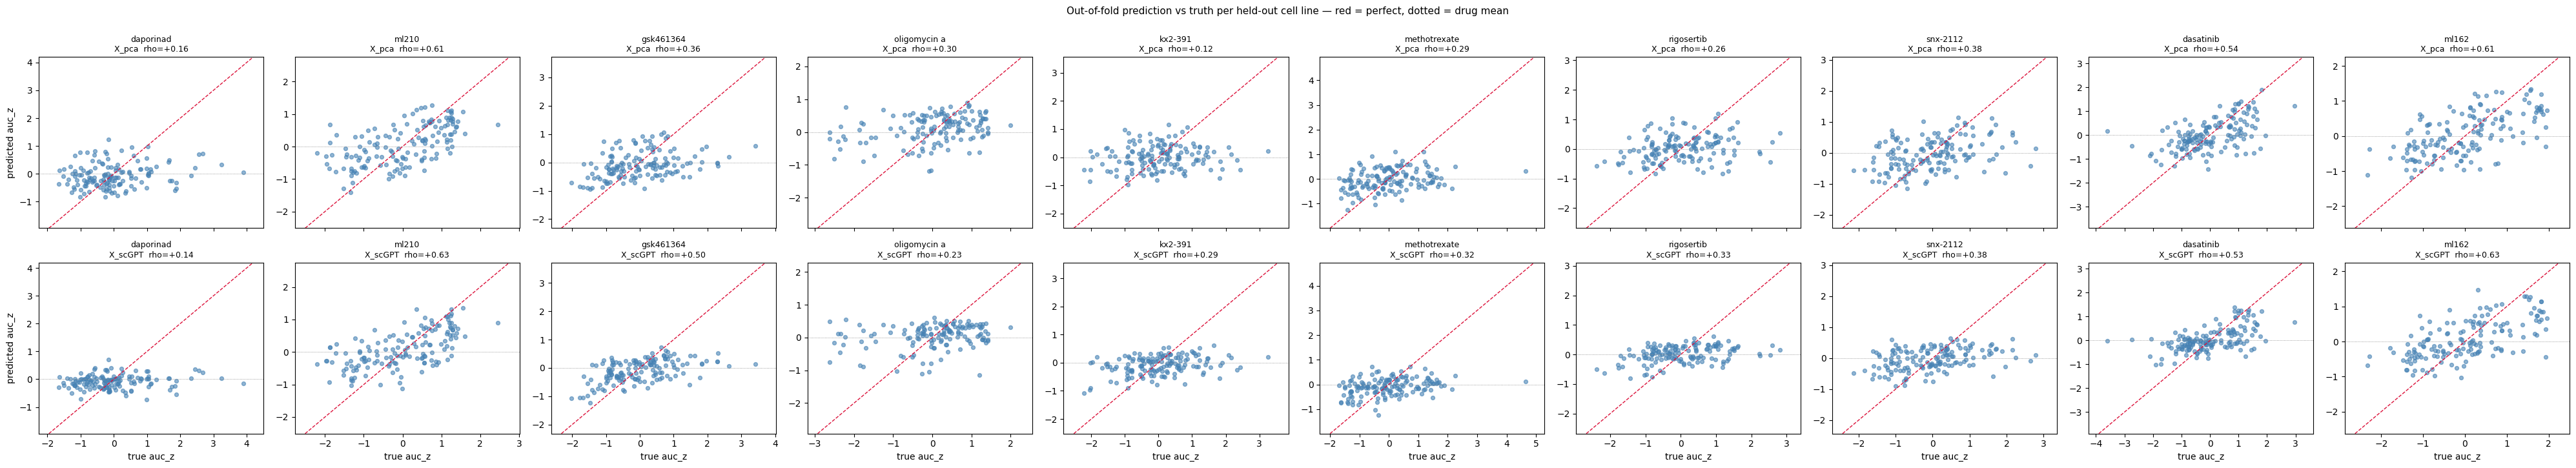

In [6]:
fig, axes = plt.subplots(len(REPS), len(DRUGS), figsize=(4 * len(DRUGS), 7.2), sharex='col')
for i, rep in enumerate(REPS):
    for j, d in enumerate(DRUGS):
        ax = axes[i, j]
        t, p = per_line[(rep, d)]
        ax.scatter(t, p, s=18, alpha=0.6, color='steelblue')
        lo, hi = np.nanmin(t) - 0.3, np.nanmax(t) + 0.3
        ax.plot([lo, hi], [lo, hi], color='crimson', ls='--', lw=1)   # perfect prediction
        ax.axhline(0, color='gray', lw=0.6, ls=':')                   # the drug's mean = null model
        rho = corr[(corr['rep'] == rep) & (corr['drug'] == d)]['spearman'].iloc[0]
        ax.set_title(f'{d}\n{rep}  rho={rho:+.2f}', fontsize=9)
        if j == 0:
            ax.set_ylabel('predicted auc_z')
        if i == len(REPS) - 1:
            ax.set_xlabel('true auc_z')
        ax.set_ylim(lo, hi)
fig.suptitle('Out-of-fold prediction vs truth per held-out cell line — red = perfect, dotted = drug mean',
             y=1.0, fontsize=11)
fig.tight_layout()
fig.savefig(OUT / 'learnability' / 'learnable_pred_vs_true.png', dpi=200)
plt.show()

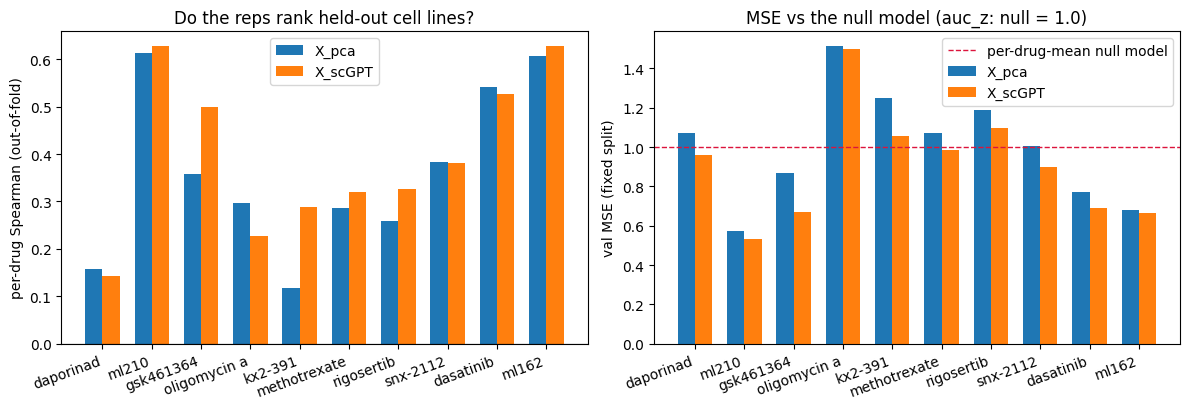

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

w = 0.35
x = np.arange(len(DRUGS))
for i, rep in enumerate(REPS):
    s = [corr[(corr['rep'] == rep) & (corr['drug'] == d)]['spearman'].iloc[0] for d in DRUGS]
    ax[0].bar(x + (i - 0.5) * w, s, w, label=rep)
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_xticks(x); ax[0].set_xticklabels(DRUGS, rotation=20, ha='right')
ax[0].set_ylabel('per-drug Spearman (out-of-fold)')
ax[0].set_title('Do the reps rank held-out cell lines?')
ax[0].legend()

for i, rep in enumerate(REPS):
    m = [fixed[(fixed['rep'] == rep) & (fixed['drug'] == d)]['model_mse'].iloc[0] for d in DRUGS]
    ax[1].bar(x + (i - 0.5) * w, m, w, label=rep)
ax[1].axhline(1.0, color='crimson', ls='--', lw=1, label='per-drug-mean null model')
ax[1].set_xticks(x); ax[1].set_xticklabels(DRUGS, rotation=20, ha='right')
ax[1].set_ylabel('val MSE (fixed split)')
ax[1].set_title('MSE vs the null model (auc_z: null = 1.0)')
ax[1].legend()

fig.tight_layout()
fig.savefig(OUT / 'learnability' / 'pca_vs_scgpt.png', dpi=200)
plt.show()

## Read-out — signal exists, and the 545-drug null result was a drug-selection artifact

**The headline.** On these 5 drugs both representations **do** rank held-out cell lines. Mean
out-of-fold per-drug Spearman:

| | mean Spearman | mean Pearson | heads beating baseline (fixed split) | best val MSE |
|---|---|---|---|---|
| `X_pca` | **0.432** | 0.416 | 3 / 5 | 0.925 |
| `X_scGPT` | **0.488** | 0.482 | 4 / 5 | 0.777 |

Compare with `2_training` §3, the same metric over all 461 variance-carrying drugs: **−0.02 (PCA) / −0.05
(scGPT)** — indistinguishable from zero. The difference is not the model, the trunk, the split or the
representation; **it is which drugs are in the loss.** The 545-drug experiment averaged a handful of
learnable heads together with hundreds of flat, inert ones, and the average is what went to zero.

Per drug, the ranking is real for three of them and weak for two:

| drug | Spearman (PCA / scGPT) | reading |
|---|---|---|
| `ml162` | 0.59 / **0.65** | GPX4 inhibitor — strong |
| `1s,3r-rsl-3` | 0.58 / **0.59** | GPX4 inhibitor — strong |
| `dasatinib` | 0.52 / **0.56** | SRC/ABL TKI — strong |
| `cay10618` | **0.36** / 0.35 | NAMPT inhibitor — moderate |
| `kx2-391` | 0.11 / **0.28** | weak for both |

That the two **ferroptosis inducers rank highest** is the best kind of sanity check: GPX4 sensitivity
is known to track a cell's lipid-peroxidation / redox state, which is exactly the kind of thing that
*is* written in the transcriptome. The filter did not just find high-variance drugs, it found drugs
whose variance has a transcriptional cause.

**scGPT vs PCA.** scGPT is ahead on every aggregate here (Spearman +0.06, 4/5 vs 3/5 heads, lower MSE)
and on 4 of the 5 drugs individually, with its clearest win exactly where PCA collapses (`kx2-391`,
0.28 vs 0.11). This is the first setting in the project where the two are **not** equivalent. It is
still only 5 drugs on one seed, and `2_training` §2 showed fold-to-fold variance large enough to swallow gaps
of this size — so this is *suggestive, not established*. Repeat over seeds before claiming it.

**Both models under-predict the extremes.** In the scatter, points hug a line flatter than the red
diagonal, and `pred_std` (0.53 PCA / 0.47 scGPT) is only about half the true spread of 1.0. The
network hedges toward each drug's mean — expected under heavy dropout + weight decay with a
broadcast, noisy label, and it means the *ranking* is far better than the *calibration*. If absolute
AUC values are ever needed (they are, for cross-drug decisions), that shrinkage has to be addressed —
lighter regularization, or fitting a per-drug linear recalibration on train lines.

### What this changes

The project's working conclusion — "the ceiling is the label, no gene representation can help" — was
**too pessimistic**. It holds *on average over 545 drugs*, and it is false on the drugs that carry
signal. The `TODO` levers aimed at the label (bulk pretraining, scDEAL-style denoising) are no longer
the only path forward; **drug selection is a first-class lever**, and a cheap one.

**Caveat, unchanged from `learnability_filter`:** the 5 drugs were chosen using all 180 lines, val/test included, so
these numbers are a **best-case diagnostic**, not an unbiased generalization estimate. The correct
follow-up is now worth the effort: select the learnable subset **train-only** (inside each CV fold),
re-run, and confirm the effect survives. That, plus multiple seeds, is what would turn this into a
result you can put in a thesis.